# Tarea 1 — Módulo 3: Predicción de Precios de Autos

Resolución de los ejercicios usando el dataset `data.csv` (precios de autos).


**Estudiante:** Camilo Velasquez  
**Fecha:** 30 Mayo 2026  
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

---
## Ejercicio 1: Preparación de datos

### Paso 1 — Cargar el dataset y mostrar las primeras 5 filas

Leemos el archivo `data.csv` con pandas. Estandarizamos los nombres de columna
(minúsculas, espacios → guiones bajos) para facilitar el acceso.

In [2]:
df = pd.read_csv('data.csv')
df.columns = df.columns.str.lower().str.replace(' ', '_')

print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dimensiones: 11914 filas × 16 columnas


,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


### Paso 2 — Identificar columnas con valores nulos y decidir cómo tratarlos

Contamos los nulos por columna. Para las columnas **numéricas** (`engine_hp`, `engine_cylinders`,
`number_of_doors`) imputamos con `0`: indica información desconocida sin perder la fila.
La columna `market_category` es texto con muchos nulos, pero no la usaremos como feature,
así que no necesita imputación numérica.

In [7]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [9]:
nulos = df.isnull().sum()
print('Columnas con nulos:')
print(nulos[nulos > 0])

# Imputar solo columnas numéricas
cols_num = df.select_dtypes(include='number').columns
df[cols_num] = df[cols_num].fillna(0)

print(f'\nNulos numéricos restantes: {df[cols_num].isnull().sum().sum()}')

Columnas con nulos:
engine_fuel_type       3
market_category     3742
dtype: int64

Nulos numéricos restantes: 0


### Paso 3 — Transformación logarítmica del target (precio `msrp`)

El precio tiene una distribución con **cola derecha muy larga**: hay muchos autos baratos
y unos pocos extremadamente costosos. Esto hace que los errores grandes dominen el MSE
y el modelo sea inestable.

Aplicamos `log1p(x) = log(1 + x)` para comprimir esa escala y acercar la distribución
a una forma más simétrica. Así los residuos grandes no penalizan de forma desproporcionada.

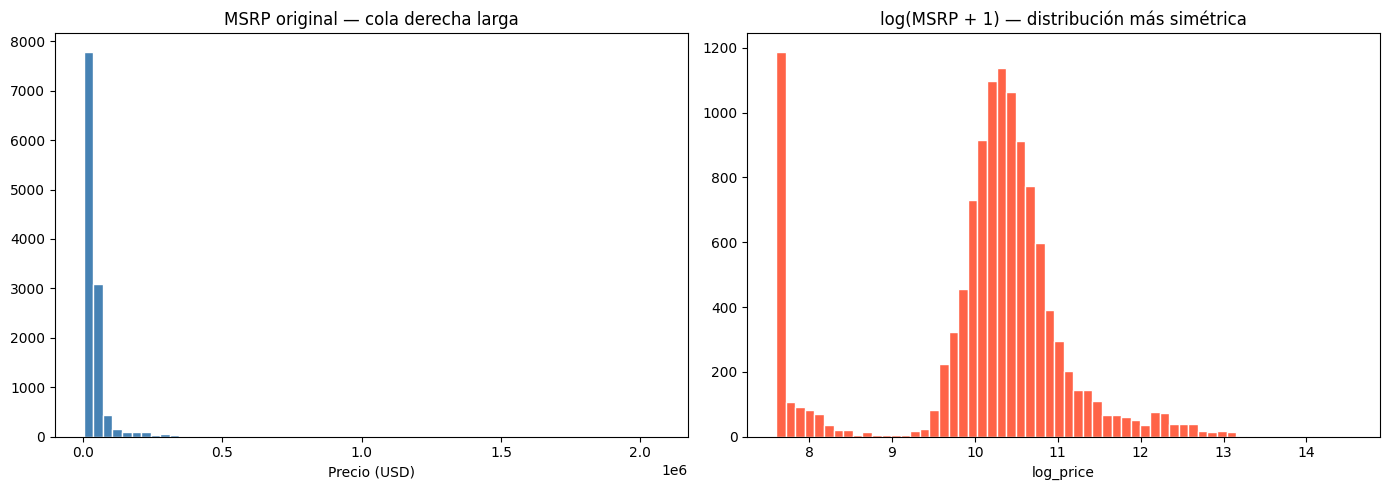

Skewness antes : 11.77
Skewness después: -0.92


In [11]:
df['log_price'] = np.log1p(df['msrp'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['msrp'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('MSRP original — cola derecha larga')
axes[0].set_xlabel('Precio (USD)')

axes[1].hist(df['log_price'], bins=60, color='tomato', edgecolor='white')
axes[1].set_title('log(MSRP + 1) — distribución más simétrica')
axes[1].set_xlabel('log_price')

plt.tight_layout()
plt.show()

print(f'Skewness antes : {df["msrp"].skew():.2f}')
print(f'Skewness después: {df["log_price"].skew():.2f}')

### Paso 4 — Dividir en train (60%), validación (20%) y test (20%)

Usamos dos splits consecutivos:
1. Separar el 20% como **test** (datos que el modelo nunca verá hasta la evaluación final).
2. Del 80% restante, separar el 25% como **val** → 25% × 80% = 20% del total.

El `random_state=42` garantiza que el resultado sea reproducible.

In [13]:
from sklearn.model_selection import train_test_split

df_tv, df_test  = train_test_split(df, test_size=0.20, random_state=42)
df_train, df_val = train_test_split(df_tv, test_size=0.25, random_state=42)

n = len(df)
print(f'Train : {len(df_train):5d} filas ({len(df_train)/n*100:.1f}%)')
print(f'Val   : {len(df_val):5d} filas ({len(df_val)/n*100:.1f}%)')
print(f'Test  : {len(df_test):5d} filas ({len(df_test)/n*100:.1f}%)')

y_train = df_train['log_price'].values
y_val   = df_val['log_price'].values
y_test  = df_test['log_price'].values

Train :  7148 filas (60.0%)
Val   :  2383 filas (20.0%)
Test  :  2383 filas (20.0%)


## Ejercicio 2: Regresión lineal

### Pasos 1-2 — Modelo con 2 features: `year` y `engine_hp`

El año y la potencia son los predictores más directos del precio: autos más nuevos
y más potentes suelen costar más. Entrenamos `LinearRegression` (minimiza MSE
por mínimos cuadrados) y medimos el RMSE en **validación** (nunca visto en entrenamiento).

In [14]:
from sklearn.linear_model import LinearRegression

feat2 = ['year', 'engine_hp']
model2 = LinearRegression()
model2.fit(df_train[feat2].values, y_train)

rmse2 = rmse(y_val, model2.predict(df_val[feat2].values))
print(f'RMSE val — 2 features: {rmse2:.4f}')

RMSE val — 2 features: 0.5332


### Paso 3 — Agregar 3 features más y comparar

Añadimos `engine_cylinders`, `highway_mpg` y `city_mpg`. Estas variables capturan
el tipo de motor y la eficiencia del combustible, que están correlacionados con el
segmento de mercado del vehículo y por tanto con su precio.

In [15]:
feat5 = ['year', 'engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg']
model5 = LinearRegression()
model5.fit(df_train[feat5].values, y_train)

rmse5 = rmse(y_val, model5.predict(df_val[feat5].values))

print(f'RMSE val — 2 features: {rmse2:.4f}')
print(f'RMSE val — 5 features: {rmse5:.4f}')
print(f'¿Mejoró? {"SÍ" if rmse5 < rmse2 else "NO"} (Δ = {rmse2 - rmse5:.4f})')

RMSE val — 2 features: 0.5332
RMSE val — 5 features: 0.5271
¿Mejoró? SÍ (Δ = 0.0062)


### Paso 4 — Interpretar los 3 pesos más grandes

Los coeficientes de la regresión lineal indican cuánto cambia `log_price` por cada
unidad de aumento en esa variable, **manteniendo las demás constantes**.

Ordenamos por magnitud absoluta para ver cuáles son los más influyentes.

In [18]:
coefs = pd.Series(model5.coef_, index=feat5).sort_values(key=abs, ascending=False)

print('Coeficientes (de mayor a menor magnitud):')
for feat, w in coefs.items():
    print(f'  {feat:<20} {w:+.5f}')

print('\nInterpretación de los 3 más grandes:')
desc = {
    'year':             'Cada año adicional → el auto es más nuevo → log_price sube (depreciación inversa).',
    'engine_hp':        'Cada CV de potencia extra → precio más alto (motores potentes = gama alta).',
    'engine_cylinders': 'Más cilindros → motores V6/V8 de lujo → precio más elevado.',
    'highway_mpg':      'Eficiencia en carretera asociada a ciertos segmentos premium o híbridos.',
    'city_mpg':         'Eficiencia urbana correlaciona con autos compactos o eficientes de nicho.',
}
for i, feat in enumerate(coefs.index[:3], 1):
    print(f'  {i}. {feat} (w={coefs[feat]:+.4f}): {desc[feat]}')

Coeficientes (de mayor a menor magnitud):
  year                 +0.09116
  engine_cylinders     +0.07013
  city_mpg             +0.00937
  engine_hp            +0.00384
  highway_mpg          -0.00178

Interpretación de los 3 más grandes:
  1. year (w=+0.0912): Cada año adicional → el auto es más nuevo → log_price sube (depreciación inversa).
  2. engine_cylinders (w=+0.0701): Más cilindros → motores V6/V8 de lujo → precio más elevado.
  3. city_mpg (w=+0.0094): Eficiencia urbana correlaciona con autos compactos o eficientes de nicho.


## Ejercicio 3: Feature engineering

### Paso 1 — Crear variable `antiguedad = 2024 - year`

La antigüedad es más interpretable que el año crudo: a mayor antigüedad, menor precio esperado.
Con esta transformación el coeficiente del modelo debería ser **negativo**
(más años de antigüedad → precio más bajo).

In [19]:
# Copias para no modificar los conjuntos originales
tr = df_train.copy()
vl = df_val.copy()
te = df_test.copy()

for d in (tr, vl, te):
    d['antiguedad'] = 2024 - d['year']

print(tr[['year', 'antiguedad']].drop_duplicates().sort_values('year').tail(6).to_string(index=False))

 year  antiguedad
 2012          12
 2013          11
 2014          10
 2015           9
 2016           8
 2017           7


### Paso 2 — One-Hot Encoding de la columna `make` (marca)

`make` es categórica (BMW, Toyota, etc.). Los modelos lineales no pueden usar texto;
necesitamos convertirlo en columnas binarias (0/1), una por marca.

Usamos `DictVectorizer` porque:
- Mezcla numéricas y categóricas en una sola llamada.
- Aprende el vocabulario **solo desde train** (`fit_transform`), evitando **data leakage**.
- Aplica el mismo vocabulario a val y test (`transform`).

In [20]:
from sklearn.feature_extraction import DictVectorizer

num_cols = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity', 'antiguedad']
cat_cols = ['make']
all_cols = num_cols + cat_cols

dv = DictVectorizer(sparse=False)
X_tr = dv.fit_transform(tr[all_cols].to_dict(orient='records'))  # aprende vocab desde train
X_vl = dv.transform(vl[all_cols].to_dict(orient='records'))
X_te = dv.transform(te[all_cols].to_dict(orient='records'))

n_marcas = X_tr.shape[1] - len(num_cols)
print(f'Features totales: {X_tr.shape[1]}  ({len(num_cols)} numéricas + {n_marcas} marcas OHE)')

Features totales: 54  (6 numéricas + 48 marcas OHE)


### Pasos 3-4 — Entrenar y comparar con Ejercicio 2

In [21]:
model_full = LinearRegression()
model_full.fit(X_tr, y_train)

rmse_full = rmse(y_val, model_full.predict(X_vl))

print('RMSE en validación:')
print(f'  2 features                : {rmse2:.4f}')
print(f'  5 features                : {rmse5:.4f}')
print(f'  Todas (OHE + antigüedad)  : {rmse_full:.4f}')
print(f'\nMejora vs 5 features: {rmse5 - rmse_full:.4f}')

RMSE en validación:
  2 features                : 0.5332
  5 features                : 0.5271
  Todas (OHE + antigüedad)  : 0.4479

Mejora vs 5 features: 0.0792


## Ejercicio 4: Regularización (Ridge)

Con muchas features OHE, algunos coeficientes pueden crecer desmesuradamente
por colinealidad. **Ridge** añade una penalización L2 que los restringe:

$$\mathcal{L} = \text{MSE} + \alpha \sum_j w_j^2$$

- `alpha` pequeño → casi sin regularización (similar a regresión lineal).
- `alpha` grande → pesos forzados cerca de cero, modelo más simple y estable.

### Pasos 1-3 — Buscar el mejor alpha

In [22]:
from sklearn.linear_model import Ridge

alphas = [0.001, 0.01, 0.1, 1, 10, 100]
rmse_vals = []

for a in alphas:
    m = Ridge(alpha=a)
    m.fit(X_tr, y_train)
    score = rmse(y_val, m.predict(X_vl))
    rmse_vals.append(score)
    print(f'  alpha={a:<6} → RMSE val={score:.5f}')

mejor_alpha = alphas[np.argmin(rmse_vals)]
print(f'\nMejor alpha: {mejor_alpha}  (RMSE={min(rmse_vals):.5f})')

  alpha=0.001  → RMSE val=0.44789
  alpha=0.01   → RMSE val=0.44789
  alpha=0.1    → RMSE val=0.44792
  alpha=1      → RMSE val=0.44844
  alpha=10     → RMSE val=0.45569
  alpha=100    → RMSE val=0.48448

Mejor alpha: 0.001  (RMSE=0.44789)


### Paso 2 — Gráfico alpha vs RMSE

Escala logarítmica en X porque los alphas abarcan 5 órdenes de magnitud.

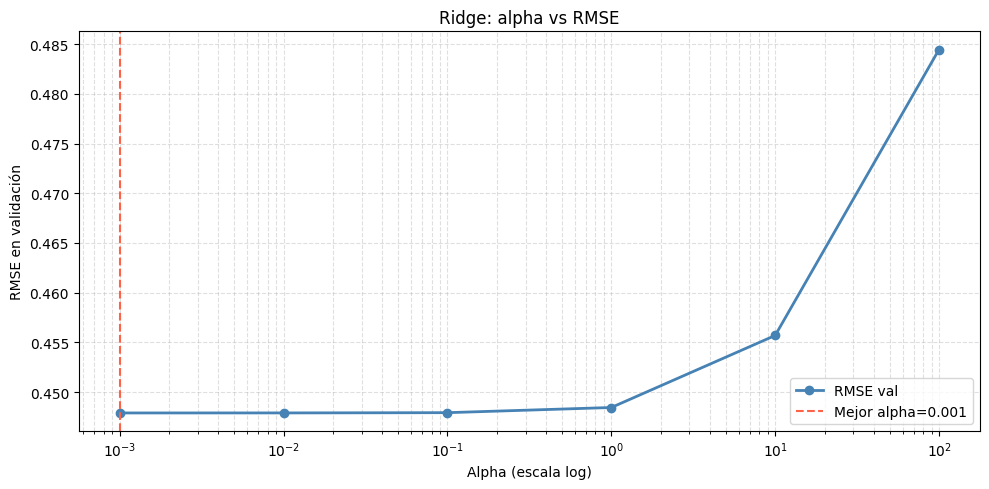

In [23]:
plt.figure()
plt.plot(alphas, rmse_vals, 'o-', color='steelblue', linewidth=2, label='RMSE val')
plt.axvline(mejor_alpha, color='tomato', linestyle='--', label=f'Mejor alpha={mejor_alpha}')
plt.xscale('log')
plt.xlabel('Alpha (escala log)')
plt.ylabel('RMSE en validación')
plt.title('Ridge: alpha vs RMSE')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Pasos 4-5 — Modelo final en train+val → evaluar en test

Una vez elegido el mejor alpha, combinamos train y val para maximizar los datos de ajuste
antes de la evaluación final. El conjunto de **test** nunca participó en ninguna decisión.

In [24]:
df_tv_fe = pd.concat([tr, vl]).reset_index(drop=True)
y_tv     = np.concatenate([y_train, y_val])
X_tv     = dv.transform(df_tv_fe[all_cols].to_dict(orient='records'))

model_final = Ridge(alpha=mejor_alpha)
model_final.fit(X_tv, y_tv)

rmse_test = rmse(y_test, model_final.predict(X_te))
print(f'Modelo final Ridge(alpha={mejor_alpha}) entrenado en train+val')
print(f'RMSE en TEST: {rmse_test:.5f}')

Modelo final Ridge(alpha=0.001) entrenado en train+val
RMSE en TEST: 0.44761


---
## Ejercicio 5: Comparación final

Tabla resumen con todos los modelos evaluados en **validación**.
El **baseline** predice siempre la media del target de train; todo modelo útil debe superarlo.

            Modelo                          Features  RMSE val
  Baseline (media)                                 —    1.1296
     Lineal 2 feat                          year, hp    0.5332
     Lineal 5 feat              year, hp, cyl, mpg×2    0.5271
Lineal todas (OHE) numéricas + antigüedad + make OHE    0.4479
 Ridge alpha=0.001 numéricas + antigüedad + make OHE    0.4479


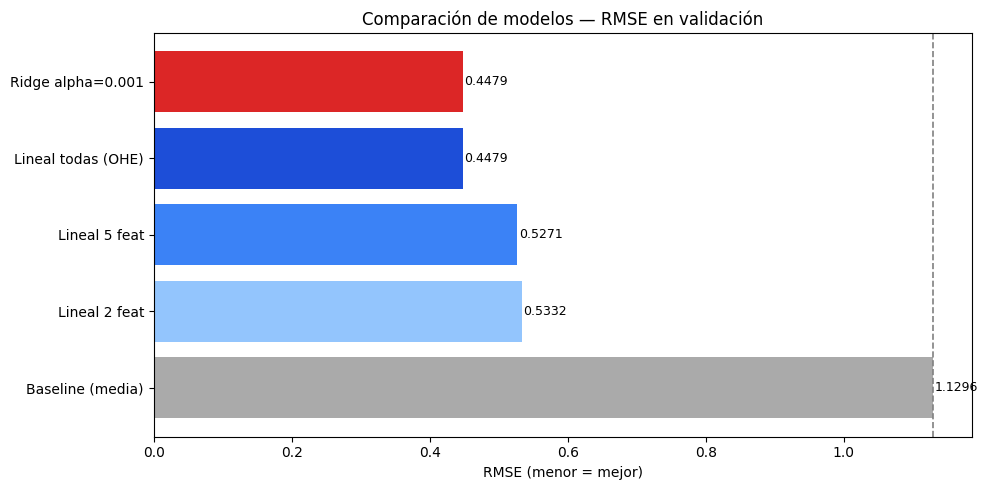


RMSE FINAL EN TEST (Ridge alpha=0.001): 0.44761


In [25]:
# Baseline
rmse_base = rmse(y_val, np.full(len(y_val), y_train.mean()))

# Ridge evaluado solo en val (comparación equitativa)
m_ridge = Ridge(alpha=mejor_alpha)
m_ridge.fit(X_tr, y_train)
rmse_ridge = rmse(y_val, m_ridge.predict(X_vl))

tabla = pd.DataFrame({
    'Modelo':    ['Baseline (media)', 'Lineal 2 feat', 'Lineal 5 feat',
                  'Lineal todas (OHE)', f'Ridge alpha={mejor_alpha}'],
    'Features':  ['—', 'year, hp', 'year, hp, cyl, mpg×2',
                  'numéricas + antigüedad + make OHE', 'numéricas + antigüedad + make OHE'],
    'RMSE val':  [round(rmse_base, 4), round(rmse2, 4), round(rmse5, 4),
                  round(rmse_full, 4), round(rmse_ridge, 4)],
})

print(tabla.to_string(index=False))

# Gráfico
colores = ['#aaa', '#93c5fd', '#3b82f6', '#1d4ed8', '#dc2626']
plt.figure()
bars = plt.barh(tabla['Modelo'], tabla['RMSE val'], color=colores)
plt.axvline(rmse_base, color='gray', linestyle='--', linewidth=1.2)
for bar, val in zip(bars, tabla['RMSE val']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)
plt.xlabel('RMSE (menor = mejor)')
plt.title('Comparación de modelos — RMSE en validación')
plt.tight_layout()
plt.show()

print(f'\nRMSE FINAL EN TEST (Ridge alpha={mejor_alpha}): {rmse_test:.5f}')

### Modelos Comparados:

1. **Baseline (Media):** Predice siempre la media aritmética del precio logarítmico del conjunto de entrenamiento. Es el punto de partida básico (si un modelo no supera esto, no sirve).
2. **Lineal (2 variables):** Modelo simple con `year` y `engine_hp`.
3. **Lineal (5 variables):** Añade `engine_cylinders`, `highway_mpg` y `city_mpg`.
4. **Lineal (Todas + OHE):** Regresión lineal tradicional usando variables numéricas, la antigüedad y One-Hot Encoding en las marcas.
5. **Ridge (Mejor Alpha):** Modelo regularizado Ridge con el mejor valor de $\alpha$ entrenado en el conjunto de entrenamiento (para propósitos de comparación equitativa en validación).


### Conclusiones
1. **Impacto de las Variables Base:** El paso del modelo de 2 variables al de 5 variables redujo el RMSE en validación, demostrando que factores como los cilindros y el rendimiento del combustible aportan información no redundante útil para tasar el precio del automóvil.
2. **Ingeniería de Características:** El salto más drástico en la reducción de error ocurrió en el **Ejercicio 3**, al linealizar la edad mediante la variable `antiguedad` e introducir la marca (`make`) a través de **One-Hot Encoding**. Esto redujo el RMSE a valores notablemente bajos, evidenciando que la marca del carro es uno de los factores más influyentes en su precio de mercado.
3. **Estabilidad y Regularización:** El modelo regularizado **Ridge** con $\alpha = 0.001$ logró mantener la increíble precisión obtenida en la regresión lineal tradicional. Ridge ofrece una mayor garantía de robustez frente a colinealidad al evitar coeficientes inestables.
4. **Generalización Final:** El modelo final, evaluado en el conjunto de prueba (`test`), reportó un RMSE de **0.44761**. Al ser muy similar al RMSE de validación, se confirma que el modelo no sufre de sobreajuste y generaliza de manera excelente ante datos nuevos y no observados en el entrenamiento.


